In [23]:
import sys
from pathlib import Path
import numpy as np


# Корень проекта (player_zoom): cwd обычно tests/ или сам player_zoom/
_root = Path.cwd().resolve()
if _root.name == "tests":
    _root = _root.parent
sys.path.insert(0, str(_root))

from src.trajectories import _gen_patterns, _gen_taus, run_pattern

from src.nb_logger import start
start()

[nb_logger] Logging to: c:\GitHub\diplom\spores_2\player_zoom\tests\test_patterns.txt


In [24]:
labels = {(0,1): 'L', (0,-1): 'R', (1,0): 'F', (-1,0): 'B'}

patterns = _gen_patterns(4)

for i, p in enumerate(patterns):
    print(i, p)

0 ((1, 0), (0, 1), (-1, 0), (0, -1))
1 ((1, 0), (0, -1), (-1, 0), (0, 1))
2 ((-1, 0), (0, 1), (1, 0), (0, -1))
3 ((-1, 0), (0, -1), (1, 0), (0, 1))
4 ((0, 1), (1, 0), (0, -1), (-1, 0))
5 ((0, 1), (-1, 0), (0, -1), (1, 0))
6 ((0, -1), (1, 0), (0, 1), (-1, 0))
7 ((0, -1), (-1, 0), (0, 1), (1, 0))


In [25]:
test_taus = _gen_taus(N=1, pattern_length=4, tau=1, seed=42)[0]
test_taus

array([0.43887844, 0.33507761, 0.08464187, 0.14140208])

In [4]:
start_state = [0, 0, 0]
run_pattern(start_state=start_state, pattern_index=0, taus=test_taus)

[array([0., 0., 0.]),
 array([0.        , 0.        , 0.43887844]),
 array([0.30332191, 0.14238267, 0.43887844]),
 array([0.30332191, 0.14238267, 0.35423657]),
 array([0.17069926, 0.09333391, 0.35423657])]

In [5]:
from scipy.optimize import minimize

In [6]:
def objective_pat7(taus):
    taus = np.array(taus)
    taus /= taus.sum()
    x, y, theta = run_pattern(start_state=start_state, pattern_index=6, taus=taus)[-1]

    return -1 * (y)**(1) + 1 * (abs(x))**(1) + 1 * abs(theta)**(1)

tau = 1
x0 = np.ones(4) / 4 * tau
result_1 = minimize(objective_pat7, x0, method='Nelder-Mead', tol=1e-10)

In [7]:
print(result_1)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -0.0628271333963254
             x: [ 2.482e-01  2.518e-01  2.561e-01  2.518e-01]
           nit: 153
          nfev: 290
 final_simplex: (array([[ 2.482e-01,  2.518e-01,  2.561e-01,  2.518e-01],
                       [ 2.482e-01,  2.518e-01,  2.561e-01,  2.518e-01],
                       ...,
                       [ 2.482e-01,  2.518e-01,  2.561e-01,  2.518e-01],
                       [ 2.482e-01,  2.518e-01,  2.561e-01,  2.518e-01]],
                      shape=(5, 4)), array([-6.283e-02, -6.283e-02, -6.283e-02, -6.283e-02,
                       -6.283e-02]))


In [8]:
traj_1 = run_pattern(start_state=start_state, pattern_index=6, taus=result_1.x)

# traj = run_pattern(start_state=start_state, pattern_index=0, taus=[0, 1, 0, 0])
for point in traj_1:
    print(point)

[0. 0. 0.]
[-0.24816054  0.          0.        ]
[-0.24816054  0.          0.25182265]
[-1.25765388e-04  6.38154559e-02  2.51822652e-01]
[-1.25765388e-04  6.38154559e-02 -1.06248343e-13]


In [9]:
print(objective_pat7(result_1.x))

-0.0628271333963254


[-1.25765388e-04  6.38154559e-02 -1.06248343e-13]


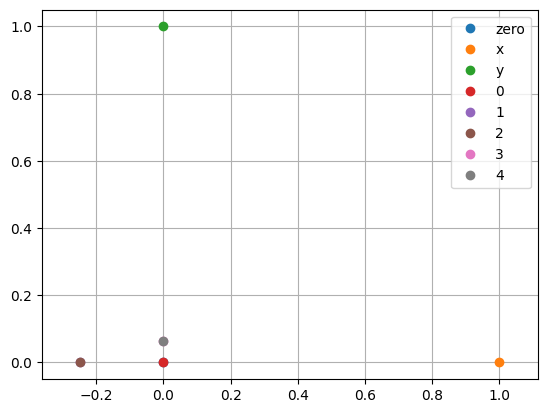

In [10]:
import matplotlib.pyplot as plt
plt.plot(0, 0, 'o', label='zero')
plt.plot(1, 0, 'o', label='x')
plt.plot(0, 1, 'o', label='y')

for i, point in enumerate(traj_1):
    plt.plot(point[0], point[1], 'o', label=f'{i}')
plt.axis('equal')
plt.legend()
plt.grid()

print(point)

In [11]:
def objective_pat0(taus):
    taus = np.array(taus)
    taus /= taus.sum()
    x, y, theta = run_pattern(start_state=start_state, pattern_index=0, taus=taus)[-1]

    return -1 * (y)**(1) + 1 * (abs(x))**(1) + 1 * abs(theta)**(1)

tau = 1
x0 = 1 * np.ones(4) / 4 * tau
result_2 = minimize(objective_pat0, x0, method='Nelder-Mead', tol=1e-10)

In [12]:
print(result_2)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -0.06282707020383448
             x: [ 2.518e-01  2.561e-01  2.518e-01  2.482e-01]
           nit: 164
          nfev: 301
 final_simplex: (array([[ 2.518e-01,  2.561e-01,  2.518e-01,  2.482e-01],
                       [ 2.518e-01,  2.561e-01,  2.518e-01,  2.482e-01],
                       ...,
                       [ 2.518e-01,  2.561e-01,  2.518e-01,  2.482e-01],
                       [ 2.518e-01,  2.561e-01,  2.518e-01,  2.482e-01]],
                      shape=(5, 4)), array([-6.283e-02, -6.283e-02, -6.283e-02, -6.283e-02,
                       -6.283e-02]))


In [13]:
traj_2 = run_pattern(start_state=start_state, pattern_index=0, taus=result_2.x)

# traj = run_pattern(start_state=start_state, pattern_index=0, taus=[0, 1, 0, 0])
for point in traj_2:
    print(point)

[0. 0. 0.]
[0.         0.         0.25180923]
[0.24806397 0.06381942 0.25180923]
[2.48063966e-01 6.38194171e-02 1.10245146e-13]
[-1.26270574e-04  6.38194171e-02  1.10245146e-13]


[-1.26270574e-04  6.38194171e-02  1.10245146e-13]


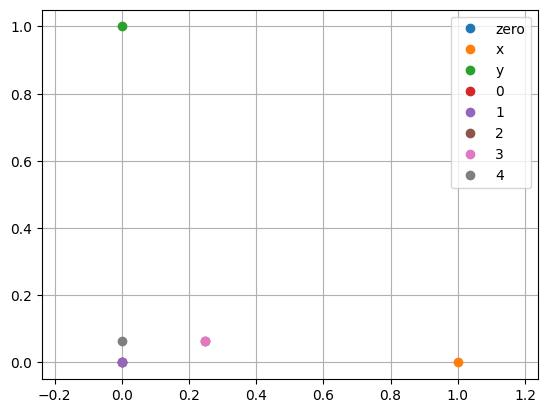

In [14]:
import matplotlib.pyplot as plt
plt.plot(0, 0, 'o', label='zero')
plt.plot(1, 0, 'o', label='x')
plt.plot(0, 1, 'o', label='y')

for i, point in enumerate(traj_2):
    plt.plot(point[0], point[1], 'o', label=f'{i}')
plt.axis('equal')
plt.legend()
plt.grid()

print(point)

In [15]:
np.concat([traj_1, traj_2])

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-2.48160535e-01,  0.00000000e+00,  0.00000000e+00],
       [-2.48160535e-01,  0.00000000e+00,  2.51822652e-01],
       [-1.25765388e-04,  6.38154559e-02,  2.51822652e-01],
       [-1.25765388e-04,  6.38154559e-02, -1.06248343e-13],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  2.51809227e-01],
       [ 2.48063966e-01,  6.38194171e-02,  2.51809227e-01],
       [ 2.48063966e-01,  6.38194171e-02,  1.10245146e-13],
       [-1.26270574e-04,  6.38194171e-02,  1.10245146e-13]])

In [16]:
import plotly.graph_objects as go


def _states_to_xyz(states):
    a = np.asarray(states, dtype=float)
    return a[:, 0], a[:, 1], a[:, 2]


def add_origin_axes(fig, L=0.12):
    """Начало координат (крупная точка) и короткие полуоси x, y, θ с подписями."""
    fig.add_trace(
        go.Scatter3d(
            x=[0.0],
            y=[0.0],
            z=[0.0],
            mode="markers",
            name="0",
            marker=dict(
                size=18,
                color="#111111",
                symbol="circle",
                line=dict(color="#ffc107", width=3),
            ),
            hovertemplate="начало (0,0,0)<extra></extra>",
        )
    )
    for end, color, lab in (
        ((L, 0.0, 0.0), "#c62828", "x"),
        ((0.0, L, 0.0), "#2e7d32", "y"),
        ((0.0, 0.0, L), "#1565c0", "θ"),
    ):
        fig.add_trace(
            go.Scatter3d(
                x=[0.0, end[0]],
                y=[0.0, end[1]],
                z=[0.0, end[2]],
                mode="lines",
                line=dict(color=color, width=5),
                showlegend=False,
                hoverinfo="skip",
            )
        )
        fig.add_trace(
            go.Scatter3d(
                x=[end[0]],
                y=[end[1]],
                z=[end[2]],
                mode="markers+text",
                marker=dict(size=8, color=color, symbol="diamond"),
                text=[lab],
                textposition="top center",
                textfont=dict(size=12, color=color, family="Arial Black"),
                showlegend=False,
                hovertemplate=f"ось {lab}<extra></extra>",
            )
        )


fig = go.Figure()
for label, tr in (("traj_1", traj_1), ("traj_2", traj_2)):
    x, y, z = _states_to_xyz(tr)
    fig.add_trace(
        go.Scatter3d(
            x=x,
            y=y,
            z=z,
            mode="lines+markers",
            name=label,
        )
    )
add_origin_axes(fig, L=0.12)
fig.update_layout(
    title="traj_1 и traj_2 — отдельные линии (нет соединения конец→начало)",
    scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="θ"),
    legend=dict(x=0.02, y=0.98),
)
fig.show()

In [17]:
import plotly.graph_objects as go

_palette = (
    "#636EFA",
    "#EF553B",
    "#00CC96",
    "#AB63FA",
    "#FFA15A",
    "#19D3F3",
    "#FF6692",
    "#B6E880",
)


def add_origin_axes(fig, L=0.12):
    fig.add_trace(
        go.Scatter3d(
            x=[0.0],
            y=[0.0],
            z=[0.0],
            mode="markers",
            name="0",
            marker=dict(
                size=10,
                color="#111111",
                symbol="circle",
                line=dict(color="#ffc107", width=3),
            ),
            hovertemplate="начало (0,0,0)<extra></extra>",
        )
    )
    for end, color, lab in (
        ((L, 0.0, 0.0), "#c62828", "x"),
        ((0.0, L/4, 0.0), "#2e7d32", "y"),
        ((0.0, 0.0, L), "#1565c0", "θ"),
    ):
        fig.add_trace(
            go.Scatter3d(
                x=[0.0, end[0]],
                y=[0.0, end[1]],
                z=[0.0, end[2]],
                mode="lines",
                line=dict(color=color, width=5),
                showlegend=False,
                hoverinfo="skip",
            )
        )
        fig.add_trace(
            go.Scatter3d(
                x=[end[0]],
                y=[end[1]],
                z=[end[2]],
                mode="markers+text",
                marker=dict(size=8, color=color, symbol="diamond"),
                text=[lab],
                textposition="top center",
                textfont=dict(size=12, color=color, family="Arial Black"),
                showlegend=False,
                hovertemplate=f"ось {lab}<extra></extra>",
            )
        )



In [18]:
from scipy.optimize import minimize, LinearConstraint, Bounds

# Какие шаблоны симулировать (индексы 0..7); остальные не считаются
pattern_indices_to_optimize = [0, 1, 2, 3, 4, 5, 6, 7]
pattern_length = 4
tau_total = 1

# Начальная точка на симплексе: sum == tau_total, все > 0
x0 = np.ones(pattern_length) / pattern_length * tau_total

# Ограничения: sum(taus) == tau_total, taus >= 0
constraint = LinearConstraint(np.ones((1, pattern_length)), lb=tau_total, ub=tau_total)
bounds = Bounds(lb=0.0, ub=np.inf)

all_patterns = _gen_patterns(pattern_length)

def make_objective(pattern_index: int):
    """Нормировка не нужна — optimizer сам держит sum=tau_total."""
    def objective(taus):
        x, y, theta = run_pattern(
            start_state=start_state, pattern_index=pattern_index, taus=taus
        )[-1]
        return -abs(y) + 10*abs(x) + 10*abs(theta)
    return objective

optimization_results = {}
optimized_trajs = {}

for pi in pattern_indices_to_optimize:
    res = minimize(
        make_objective(pi), x0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraint,
        tol=1e-10,
    )
    optimization_results[pi] = res
    optimized_trajs[pi] = run_pattern(
        start_state=start_state, pattern_index=pi, taus=res.x
    )

for pi in pattern_indices_to_optimize:
    r = optimization_results[pi]
    end = optimized_trajs[pi][-1]
    print(
        f"pattern {pi}: success={r.success}, fun={r.fun:.6g}, "
        f"end (x,y,θ)=({end[0]:.6g}, {end[1]:.6g}, {end[2]:.6g})\n"
        f'result.x {r.x}'
    )
    for p in patterns[pi]:
        print(f'{labels[tuple(p)]} -> ', end='')
    print('\n')


pattern 0: success=True, fun=-0.0624131, end (x,y,θ)=(-8.90931e-09, 0.0624132, -4.41613e-11)
result.x [0.23091035 0.2727087  0.23091035 0.26547059]
F -> L -> B -> R -> 

pattern 1: success=True, fun=-0.0624131, end (x,y,θ)=(8.90931e-09, -0.0624132, -4.41613e-11)
result.x [0.23091035 0.2727087  0.23091035 0.26547059]
F -> R -> B -> L -> 

pattern 2: success=True, fun=-0.0624131, end (x,y,θ)=(-8.90931e-09, -0.0624132, 4.41613e-11)
result.x [0.23091035 0.2727087  0.23091035 0.26547059]
B -> L -> F -> R -> 

pattern 3: success=True, fun=-0.0624131, end (x,y,θ)=(8.90931e-09, 0.0624132, 4.41613e-11)
result.x [0.23091035 0.2727087  0.23091035 0.26547059]
B -> R -> F -> L -> 

pattern 4: success=True, fun=-0.062413, end (x,y,θ)=(1.24436e-08, -0.0624132, -3.81203e-11)
result.x [0.26547057 0.23091038 0.27270867 0.23091038]
L -> F -> R -> B -> 

pattern 5: success=True, fun=-0.062413, end (x,y,θ)=(1.24436e-08, 0.0624132, 3.81203e-11)
result.x [0.26547057 0.23091038 0.27270867 0.23091038]
L -> B -

In [19]:
fig_opt = go.Figure()

arrow_frac = 0.35  # доля длины сегмента, которую занимает стрелка (подберите)

for i, pi in enumerate(sorted(optimized_trajs.keys())):
    tr = optimized_trajs[pi]
    a = np.asarray(tr, dtype=float)
    c = _palette[i % len(_palette)]

    # линии + точки
    fig_opt.add_trace(
        go.Scatter3d(
            x=a[:, 0], y=a[:, 1], z=a[:, 2],
            mode="lines+markers",
            name=f"pattern {pi}",
            line=dict(color=c, width=5),
            marker=dict(size=4, color=c),
        )
    )

    # стрелочки по центру каждого отрезка
    p0 = a[:-1]
    p1 = a[1:]
    mid = 0.5 * (p0 + p1)
    d = p1 - p0
    u = d * arrow_frac  # укоротим, чтобы было "внутри" сегмента

    fig_opt.add_trace(
        go.Cone(
            x=mid[:, 0], y=mid[:, 1], z=mid[:, 2],
            u=u[:, 0],   v=u[:, 1],   w=u[:, 2],
            anchor="tail",
            showscale=False,
            colorscale=[[0, c], [1, c]],
            sizemode="absolute",
            sizeref=0.02,  # подберите под масштаб
            name=f"pattern {pi} arrows",
        )
    )

add_origin_axes(fig_opt, L=0.12)

fig_opt.update_layout(
    title="Оптимизированные траектории — линии + стрелки посередине",
    scene=dict(
        xaxis_title="x", yaxis_title="y", zaxis_title="θ",
        aspectmode="manual", aspectratio=dict(x=1, y=1, z=1)
    ),
    legend=dict(x=0.02, y=0.98),
)
fig_opt.show()

In [20]:
import numpy as np
import plotly.graph_objects as go

def plot_optimized_trajs_for_taus(
    taus,
    get_optimized_trajs,
    palette,
    pattern_indices=None,
    arrow_frac=0.35,
    arrow_sizeref=0.02,
    line_width=5,
    marker_size=4,
    L_axes=0.12,
    title="Оптимизированные траектории — линии + стрелки посередине",
):
    """get_optimized_trajs: (tau_total) или (tau_total, pattern_indices) — см. get_optimized_trajs_for_tau."""
    fig = go.Figure()

    for tau in taus:
        if pattern_indices is not None:
            optimized_trajs = get_optimized_trajs(tau, pattern_indices)
        else:
            optimized_trajs = get_optimized_trajs(tau)

        for pi in sorted(optimized_trajs.keys()):
            a = np.asarray(optimized_trajs[pi], dtype=float)
            c = palette[pi % len(palette)]  # цвет закреплён за паттерном, не зависит от tau

            # линии + точки
            fig.add_trace(
                go.Scatter3d(
                    x=a[:, 0], y=a[:, 1], z=a[:, 2],
                    mode="lines+markers",
                    name=f"tau={round(tau, 3)} | pattern {pi}",
                    line=dict(color=c, width=line_width),
                    marker=dict(size=marker_size, color=c),
                )
            )

            # стрелки по центру каждого сегмента
            if len(a) >= 2:
                p0 = a[:-1]
                p1 = a[1:]
                mid = 0.5 * (p0 + p1)
                d = p1 - p0
                u = d * arrow_frac

                fig.add_trace(
                    go.Cone(
                        x=mid[:, 0], y=mid[:, 1], z=mid[:, 2],
                        u=u[:, 0],   v=u[:, 1],   w=u[:, 2],
                        anchor="tail",
                        showscale=False,
                        colorscale=[[0, c], [1, c]],
                        sizemode="absolute",
                        sizeref=arrow_sizeref,
                        name=f"tau={round(tau, 3)} | pattern {pi} arrows",
                    )
                )

    add_origin_axes(fig, L=L_axes)

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="x", yaxis_title="y", zaxis_title="θ",
            aspectmode="manual",
            aspectratio=dict(x=2, y=1, z=1),
        ),
        legend=dict(x=0.02, y=0.98),
    )

    return fig

In [21]:
# =[0, 3, 5, 6]
# [4, 5, 6, 7]
# [0, 1, 2, 3]
# [0, 1, 2, 3]
def get_optimized_trajs_for_tau(tau_total, pattern_indices=np.arange(8)):
    """Пересчёт оптимизации; pattern_indices — подмножество шаблонов, иначе pattern_indices_to_optimize."""
    indices = (
        pattern_indices if pattern_indices is not None else pattern_indices_to_optimize
    )
    x0 = np.ones(pattern_length) / pattern_length * tau_total
    constraint = LinearConstraint(
        np.ones((1, pattern_length)), lb=tau_total, ub=tau_total
    )
    out = {}
    for pi in indices:
        res = minimize(
            make_objective(pi),
            x0,
            method="SLSQP",
            bounds=bounds,
            constraints=constraint,
            tol=1e-10,
        )
        out[pi] = run_pattern(
            start_state=start_state, pattern_index=pi, taus=res.x
        )
    return out


st = 1
fn = 5
x = np.arange(st, fn, st)
y = fn * ((np.log(x) - np.log(st)) / (np.log(fn) - np.log(st))) * (fn - st) / fn + st

fig = plot_optimized_trajs_for_taus(
    taus=y,
    get_optimized_trajs=get_optimized_trajs_for_tau,
    palette=_palette,
)
fig.show()

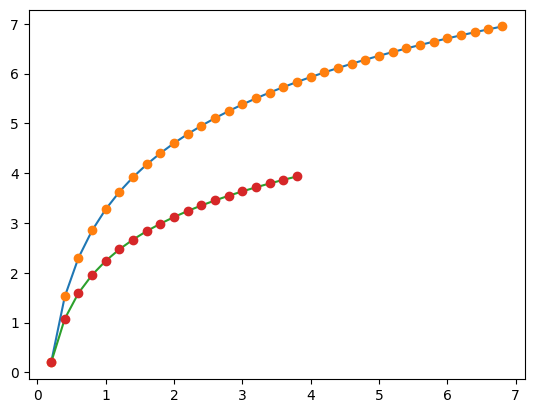

In [22]:
st = 0.2
fn = 7
x = np.arange(st, fn, st)
y = fn * ((np.log(x) - np.log(st)) / (np.log(fn) - np.log(st))) * (fn - st) / fn + st
plt.plot(x, y)
plt.plot(x, y, 'o')
plt.grid()

st = 0.2
fn = 4
x = np.arange(st, fn, st)
y = fn * ((np.log(x) - np.log(st)) / (np.log(fn) - np.log(st))) * (fn - st) / fn + st
plt.plot(x, y)
plt.plot(x, y, 'o')
plt.grid()